## 

# Projet d'Analyse de Données — Sleep Efficiency Dataset
### 4MA - INSA Toulouse 2025–2026

---

## Problématique

**Quels sont les facteurs comportementaux, physiologiques et démographiques qui structurent la qualité du sommeil, et peut-on identifier des profils typiques de dormeurs ?**

Nous étudions le jeu de données *Sleep Efficiency* disponible sur Kaggle ([lien](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)), qui recense 452 individus décrits par leurs habitudes de sommeil, leur mode de vie et leurs paramètres physiologiques de sommeil.

**Objectifs du projet :**
1. Évaluer la qualité du jeu de données (valeurs manquantes, aberrantes, redondances)
2. Mettre en évidence des axes latents structurant l'espace des individus via une **FAMD** (Analyse Factorielle de Données Mixtes), méthode adaptée à la présence simultanée de variables quantitatives et qualitatives
3. Identifier des groupes homogènes de dormeurs via un **clustering** (CAH + k-means)
4. Interpréter les résultats en lien avec la problématique

**Justification du choix du dataset :**  
Ce jeu de données présente un mélange naturel de variables quantitatives continues (durée, efficacité, pourcentages de phases) et de variables catégorielles (genre, tabagisme), ce qui en fait un cas d'usage idéal pour la FAMD. Le sommeil et ses liens avec le mode de vie constituent par ailleurs un sujet qui nous tient à cœur, en tant qu'étudiants attirés par les sciences humaines, ce dataset représente pour nous une occasion concrète de montrer comment les statistiques peuvent éclairer des comportements du quotidien.

### 0. Importation des bibliothèques 

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

### 1. Nettoyage et préparation du dataset

Cette section a pour objectif de :
- Charger et inspecter le jeu de données
- Vérifier la qualité des données
- Identifier et traiter les valeurs manquantes
- Détecter et traiter les outliers


##### 1.1 Chargement des données et premier aperçu

In [32]:
df = pd.read_csv('Sleep_Efficiency.csv')
display( 
    df.head().style.background_gradient(cmap='BuPu')
)
print("Dimensions:", df.shape)
df.info()

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.000000,0.880000,18,70,12,0.000000,0.000000,0.000000,Yes,3.000000
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.000000,0.660000,19,28,53,3.000000,0.000000,3.000000,Yes,3.000000
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.000000,0.890000,20,70,10,1.000000,0.000000,0.000000,No,3.000000
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.000000,0.510000,23,25,52,3.000000,50.000000,5.000000,Yes,1.000000
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.000000,0.760000,27,55,18,3.000000,0.000000,3.000000,No,3.000000


Dimensions: (452, 15)
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    str    
 3   Bedtime                 452 non-null    str    
 4   Wakeup time             452 non-null    str    
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    str    
 14  Exercise frequency      446 non


Le jeu de données contient **452 observations** et **15 variables**, dont :

- **5 variables entières** : ID, Age, REM, Deep et Light sleep percentage  
- **6 variables numériques continues** : Sleep duration, Sleep efficiency, Awakenings, Caffeine, Alcohol, Exercise frequency  
- **4 variables textuelles**: Gender, Bedtime, Wakeup time, Smoking status  

##### 1.2 Description des variables :

Pour chaque individu, on observe les **15 variables** suivantes :

* `ID` : Identifiant unique de l'individu
* `Age` : Âge en années
* `Gender` : Genre de l'individu (Male / Female)
* `Bedtime` : Heure de coucher (format datetime)
* `Wakeup time` : Heure de réveil (format datetime)
* `Sleep duration` : Durée totale du sommeil en heures
* `Sleep efficiency` : Proportion du temps au lit effectivement passé à dormir (entre 0 et 1)
* `REM sleep percentage` : Part du sommeil passée en phase REM (%)
* `Deep sleep percentage` : Part du sommeil passée en sommeil profond (%)
* `Light sleep percentage` : Part du sommeil passée en sommeil léger (%)
* `Awakenings` : Nombre de réveils nocturnes
* `Caffeine consumption` : Quantité de caféine consommée dans les 24h précédant le coucher (mg)
* `Alcohol consumption` : Quantité d'alcool consommée dans les 24h précédant le coucher (unités)
* `Smoking status` : Statut tabagique de l'individu (Yes / No)
* `Exercise frequency` : Fréquence d'activité physique hebdomadaire (jours/semaine)



In [33]:
n_duplicated = df.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df_aux = pd.DataFrame({
    'n_unique':df.nunique(),
    'n_missing':df.isna().sum(),
    'missing_ratio':df.isna().mean(),
    'dtype':df.dtypes.values
})

display(
    df_aux.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

Number of duplicated rows: 0



,n_unique,n_missing,missing_ratio,dtype
ID,452,0,0.00%,int64
Age,61,0,0.00%,int64
Gender,2,0,0.00%,str
Bedtime,424,0,0.00%,str
Wakeup time,434,0,0.00%,str
Sleep duration,9,0,0.00%,float64
Sleep efficiency,50,0,0.00%,float64
REM sleep percentage,13,0,0.00%,int64
Deep sleep percentage,29,0,0.00%,int64
Light sleep percentage,29,0,0.00%,int64


Le tableau révèle 4 variables avec des valeurs manquantes, toutes inférieures à 6%, ces taux étant faibles, nous avons choisi de remplir ces valeurs manquantes plutôt que de supprimer les lignes concernées, afin de ne pas perdre d'information.

On note également que `Bedtime` et `Wakeup time` affichent une très haute cardinalité (424 et 434 valeurs uniques sur 452), ce qui confirme leur caractère quasi-individuel et justifie leur transformation en variable `bedtime_hour` avant suppression.

Aucun doublon n'a été détecté dans le jeu de données ce qui est confirmé par la variable `ID` qui présente bien 452 valeurs uniques.

##### 1.3 Suppression des colonnes redondantes

- La variable `ID` n'apportant aucune information est supprimée.
- Les variables `Bedtime` et `Wakeup time`, représentées sous forme de chaînes de caractères, sont redondantes avec `Sleep duration` qui capture déjà l'information essentielle. On extrait néanmoins une variable numérique `bedtime_hour` représentant l'heure du coucher, puis les deux colonnes originales sont supprimées.

In [34]:
df['Bedtime'] = pd.to_datetime(df['Bedtime'])
df['bedtime_hour'] = df['Bedtime'].dt.hour + df['Bedtime'].dt.minute / 60

# Normalisation : les heures entre 20h et 23h59 deviennent négatives (avant minuit)
# afin de représenter la continuité temporelle (20h=−4, 23h=−1, 0h=0, 4h=4)
df['bedtime_hour'] = df['bedtime_hour'].apply(lambda h: h - 24 if h >= 20 else h)

cols_to_drop = ['ID', 'Bedtime', 'Wakeup time']
df.drop(columns=cols_to_drop, inplace=True)

##### 1.4 Gestion des valeurs manquantes

Les 4 variables concernées (`Awakenings`, `Caffeine consumption`, `Alcohol consumption`, `Exercise frequency`) présentent toutes un taux inférieur à 6%. 


In [47]:
cols_to_impute = ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']

for col in cols_to_impute:
    med_val = df[col].median()
    df[col] = df[col].fillna(med_val)


print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Age                       0
Gender                    0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Smoking status            0
Exercise frequency        0
bedtime_hour              0
dtype: int64


##### 1.5 Détection des outliers

Nous utilisons des boîtes à moustaches pour visualiser la distribution 
de chaque variable quantitative et repérer les valeurs aberrantes.

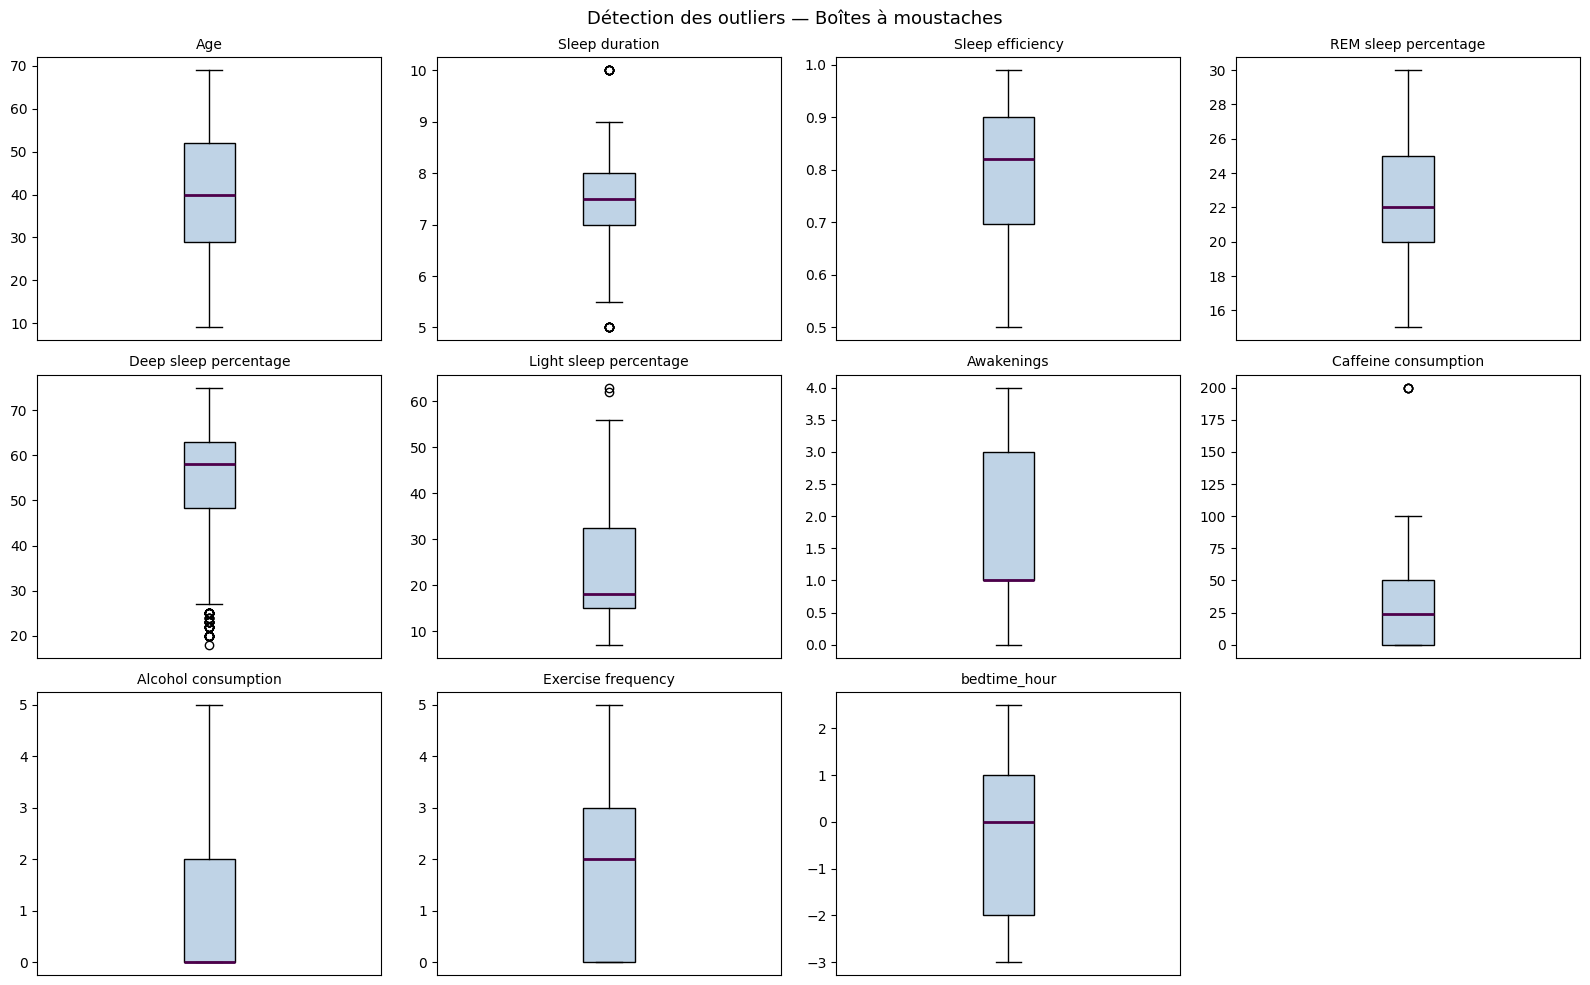

In [44]:
quant_cols = ['Age', 'Sleep duration', 'Sleep efficiency', 
              'REM sleep percentage', 'Deep sleep percentage',
              'Light sleep percentage', 'Awakenings', 
              'Caffeine consumption', 'Alcohol consumption', 
              'Exercise frequency', 'bedtime_hour']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#BFD3E6'),
                    medianprops=dict(color='#4D004B', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# On cache le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('Détection des outliers — Boîtes à moustaches', fontsize=13)
plt.tight_layout()
plt.show()